Manifold learning
---
This notebook demonstrates a series of simple experiments to learn an underlying parameter manifold of spherical spaces.

In [1]:
import itertools
import torch
import tqdm
import matplotlib.pyplot as plt
import matplotlib.colorbar as colorbar
import numpy as np

from matplotlib import patches

# Local imports
import sys
import os
from os.path import dirname as up
from dantro._import_tools import import_module_from_path
root = up(os.path.dirname(os.getcwd()))
sys.path.append(root)
include = import_module_from_path(mod_path=root, mod_str="include")
model_plots = import_module_from_path(mod_path=root, mod_str="model_plots")
from include import neural_net, colors

# Use a custom style sheet
plt.style.use('model_plots.plot_style')
%matplotlib inline
page_width = 6.47453

# Colormap
from dantro.plot.utils import ColorManager
cm = ColorManager(
    cmap={'continuous': True, 'from_values': {0: colors['c_darkblue'], 0.5: colors['c_yellow'], 1: colors['c_red']}},
)

REMARK   color_mngr        Configuring a linear colormap 'from values'. 


# Simple example: parametrising the circle
We begin with a simple test case: given a radius $R$, learn values $(x, y)$ such that $f(x, y):= x^2 + y^2 - R^2 = 0$. We fix a single value $R$ and generate a training dataset of $n$ tuples $(R, z_i)$, with $z_i \in [-1, 1]$. The goal is to learn to parametrise the manifold $f(x, y)=0$.

In [2]:
def make_training_dset(R, n, d):
    # Generate grid points in [-1, 1] in d dimensions and prepend the radius
    grid_1d = torch.linspace(-1, 1, n)
    grid_points = itertools.product(grid_1d, repeat=d)

    # Add R as the first coordinate in each point
    data = torch.tensor([[R, *point] for point in grid_points], dtype=torch.float32)

    return data

def setup_sphere_training(d: int, n: int, R: float, *, batch_size: int = None, mask_boundary: bool = True, **nn_kwargs) -> dict:

    """ Returns a dictionary of neural network and training data for a manifold learning of a sphere in d dimensions with n training points"""

    # Default neural network architecture, modified by nn_kwargs
    _nn_kwargs = dict(num_layers=1, nodes_per_layer=dict(default=6), activation_funcs=dict(default='tanh'), biases=dict(default=[-1, 1]))
    _nn_kwargs.update(**nn_kwargs)

    # Dictionary of all required information
    res = dict(
        R=R,
        n=n,
        NN=neural_net.FeedForwardNN(input_size=1+d, output_size=1+d, **_nn_kwargs),
        training_data=make_training_dset(R, n, d),
        pred_loss=[], div_loss=[]
    )

    # Split training data into batches
    if batch_size is None:
        batch_size = len(res['training_data'])
    res['training_batches'] = res['training_data'].split(batch_size, 0)

    # Create masks for the diversity loss. The diversity loss increases the minimum pairwise distance between points.
    # We exclude the diagonal as well the distance between boundary points to allow for closed manifolds.
    if mask_boundary:
        boundary_indices = []
        for batch in res['training_batches']:
            batch_boundary_indices = []
            for i, point in enumerate(batch):
                if any([_p in (-1, 1) for _p in point[1:]]):
                    batch_boundary_indices.append(i)
            boundary_indices.append(batch_boundary_indices)
    masks = [torch.ones((len(b), len(b))).bool() for b in res['training_batches']]
    for idx, m in enumerate(masks):
        m.fill_diagonal_(False)
        if mask_boundary:
            if m.shape[0] > 3:
                for i in boundary_indices[idx]:
                    for j in boundary_indices[idx]:
                        m[i, j] = False
    res['masks'] = masks

    return res

def sphere_training(data_dict: dict, *, n_epochs, eta = 1e-1, k_osc = 0, show_pbar: bool = True):
    """ Trains a neural network on sphere training data. Eta balances the prediction loss and diversity loss.
    If specified, an oscillating circle with periodicity k_osc is learned -- this allows controlling the 'complexity' of the space. """
    for epoch in tqdm.trange(n_epochs) if show_pbar else range(n_epochs):
        epoch_pred_loss = 0
        epoch_div_loss = 0
        for i, batch in enumerate(data_dict['training_batches']):

            # Make predictions
            preds = data_dict['NN'](batch)

            # Calculate the pairwise distances
            X_norm = (preds ** 2).sum(dim=1).unsqueeze(1)  # Shape: (N, 1)

            # Pairwise squared distance matrix: (N x N)
            dist_squared = (X_norm + X_norm.T - 2.0 * preds @ preds.T).clamp(min=0.0)

            # Penalise the minimum distance after applying the mask
            div_loss = torch.masked_select(dist_squared, data_dict['masks'][i]).min()

            # Prediction loss
            if k_osc == 0:
                pred_loss = (((preds**2).sum(dim=-1) - data_dict['R']**2)**2).sum()
            else:
                pred_loss = (((preds**2).sum(dim=-1) - 0.2*data_dict['R']*torch.sin(k_osc * torch.arctan2(*preds.flip(dims=[1]).transpose(0, 1))) - data_dict['R']**2)**2).sum()

            loss = pred_loss - eta*div_loss
            loss.backward()
            data_dict['NN'].optimizer.step()
            data_dict['NN'].optimizer.zero_grad()
            epoch_pred_loss += pred_loss.detach()
            epoch_div_loss += div_loss.detach()

        data_dict['pred_loss'].append(epoch_pred_loss / len(data_dict['training_batches']))
        data_dict['div_loss'].append(epoch_div_loss / len(data_dict['training_batches']))

def plot_1d_results(data_dict, z_space, *, fig = None, ax = None, add_cbar: bool = True, show_grid: bool = False):

    # Plot to exisiting axis or create new
    if ax is None:
        fig, ax = plt.subplots(figsize=(page_width/3, page_width/3))

    ax.add_patch(
        patches.Circle((0, 0), data_dict['R'], lw=1, fill=False, ls='dotted')
    )
    ax.set(xlim=(-1.5*data_dict['R'], +1.5*data_dict['R']), ylim=(-1.5*data_dict['R'], 1.5*data_dict['R']))
    ax.tick_params(labelleft=False, labelbottom=False, length=0)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.grid(visible=show_grid)

    # Create a dataset of test points
    test_space = torch.stack([torch.cat([torch.tensor([data_dict['R'], ]), z.reshape(1, )]) for z in z_space if z not in data_dict['training_data'][:, 1]])

    # Plot the results on the test points
    im = ax.scatter(
        *data_dict['NN'](test_space).detach().transpose(0, 1), c=test_space[:, -1], cmap=cm.cmap, vmin=z_space.min(), vmax=z_space.max(),
        zorder=-2
    )

    # Show the results on the original training data
    ax.scatter(*data_dict['NN'](data_dict['training_data']).detach().transpose(0, 1),
               c=data_dict['training_data'][:, -1], cmap=cm.cmap, vmin=z_space.min(), vmax=z_space.max(), lw=1, ec='k')

    # Add a colourbar, if specified
    if add_cbar and fig is not None:
        cbar_ax = fig.add_axes([0.3, 0.0, 0.4, 0.03])
        cbar = colorbar.Colorbar(cbar_ax, im, orientation='horizontal')
        cbar.set_ticks(ticks=[z_space.min(), z_space.max()], labels=[fr'$z={z_space.min():>.0f}$', fr'$z=+{z_space.max():>.0f}$'])
        cbar.ax.tick_params(axis='x', which='both', length=0, width=0)
        cbar.outline.set_linewidth(0.)

    if fig is not None:
        return fig, ax

def setup_2D_sphere_plot(R = 0.8):

    fig, axs = plt.subplots(figsize=(page_width, page_width/4), ncols=4, subplot_kw={'projection': '3d'}, gridspec_kw={'wspace': 0})

    # Create spherical coordinates
    u = np.linspace(0, 2 * np.pi, 20)
    v = np.linspace(0, np.pi, 20)
    u, v = np.meshgrid(u, v)

    # Parametrize the unit sphere
    x = R * np.cos(u) * np.sin(v)
    y = R * np.sin(u) * np.sin(v)
    z = R * np.cos(v)

    # Add colourbar etc.
    fig.subplots_adjust(wspace=0, left=0, right=0.98)
    for ax in axs:
        ax.axis('off')
        ax.plot_wireframe(x, y, z, color=colors['c_darkgrey'], alpha=1, lw=0.1, zorder=-1)
        ax.set(xlim=(-0.6, 0.6), ylim=(-0.6, 0.6), zlim=(-0.6, 0.6), box_aspect=[1, 1, 1])
        ax.patch.set(alpha=0)
    for idx in [0, 2]:
        axs[idx].view_init(azim=20)
        axs[idx+1].view_init(azim=200)

    ax = fig.add_axes([0, 0, 0.49, 1], zorder=-1)
    ax.axvspan(0, 1, color=colors['c_pink'], alpha=0.2, lw=0)
    ax.axis('off')
    ax.text(0.5, 0.05, 'Training points', color=colors['c_red'], ha='center')
    ax.set_xlim(0, 1)

    ax = fig.add_axes([0.49, 0, 0.49, 1], zorder=-1)
    ax.axvspan(0, 1, color=colors['c_lightblue'], alpha=0.2, lw=0)
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.text(0.5, 0.05, 'Test points', color=colors['c_darkblue'], ha='center')

    cbar_ax = fig.add_axes([0.99, 0, 0.01, 1])
    cbar = colorbar.Colorbar(cbar_ax, cmap=cm.cmap, orientation='vertical')
    cbar.set_label(label=r'Azimuthal angle $\varphi$', labelpad=-12)
    cbar.set_ticks([0, 1], labels=[r'$-\pi$', r'$+\pi$'])
    cbar.ax.tick_params(axis='y', which='both', length=0, width=0)
    cbar.outline.set_linewidth(0.)

    return fig, axs

Let's generate an ensemble of training sets and neural networks for various numbers of training points:

In [3]:
# n goes from 2 to 10
sphere_ensemble = [setup_sphere_training(d=1, n=n, R=0.8) for n in range(2, 11)]

for d in tqdm.tqdm(sphere_ensemble, total=len(sphere_ensemble)):
    sphere_training(d, n_epochs=2*max(5000, 5000 + 9000*(d['n']-5)), show_pbar=False)

100%|██████████| 9/9 [02:08<00:00, 14.29s/it]


We can look at the training loss for each ensemble member:

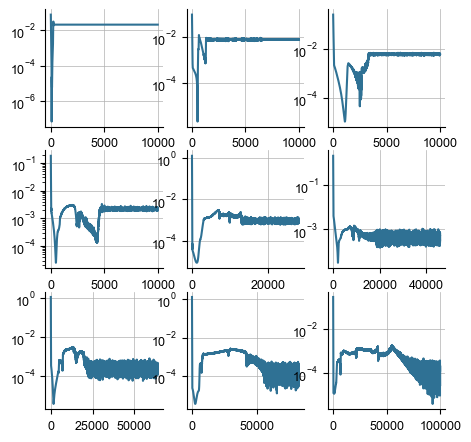

In [4]:
fig, axs = plt.subplots(ncols=3, nrows=3, figsize=(4, 4))
for idx, d in enumerate(sphere_ensemble):
    axs.flatten()[idx].plot(d['pred_loss'])
    axs.flatten()[idx].set(yscale='log')

We can also evaluate the results on a small and large training dataset:

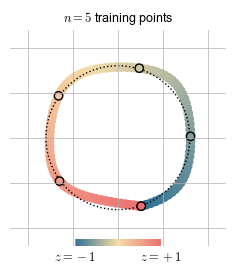

In [5]:
fig, ax = plot_1d_results(sphere_ensemble[4], z_space=torch.linspace(-1, 1, 100), show_grid=True)
ax.set_title(r'$n=5$ training points');

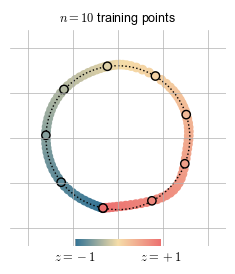

In [7]:
fig, ax = plot_1d_results(sphere_ensemble[-1], z_space=torch.linspace(-1, 1, 100), show_grid=True)
ax.set_title(r'$n=10$ training points');

## 1D osciallating circle
Now we look at a more complex, one-dimensional example of an 'oscillating' circle $$x^2 + y^2 - A \sin (k \arctan2 (y, x)) = R^2:$$

In [9]:
# 5 training points
osc_ex_small = setup_sphere_training(d=1, n=5, R=0.8)
sphere_training(osc_ex_small, n_epochs=15000, k_osc=6)

100%|██████████| 15000/15000 [00:04<00:00, 3172.07it/s]


In [10]:
# 10 training points
osc_ex_med = setup_sphere_training(d=1, n=10, R=0.8, num_layers=3, nodes_per_layer=dict(default=10))
sphere_training(osc_ex_med, n_epochs=50000, k_osc=6, eta=3e-1)

100%|██████████| 50000/50000 [00:29<00:00, 1691.66it/s]


In [11]:
# 20 training points
osc_ex_large = setup_sphere_training(d=1, n=20, R=0.8, num_layers=3, nodes_per_layer=dict(default=10))
sphere_training(osc_ex_large, n_epochs=350000, k_osc=6, eta=3e-1)

100%|██████████| 350000/350000 [04:39<00:00, 1254.43it/s]


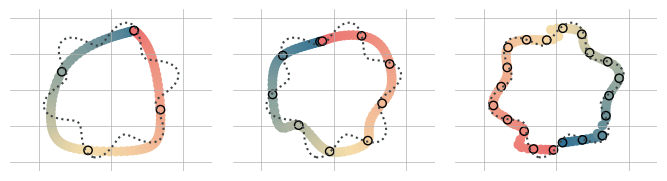

In [12]:
fig, axs = plt.subplots(ncols=3, figsize=(page_width, page_width/4), gridspec_kw={'wspace': 0.1})

# Create grid
x = np.linspace(-2, 2, 400)
y = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x, y)

# Parameters
R = 0.8
A = 0.2*R

for idx, k in enumerate([6, 6, 6]):

    # Function definition
    theta = np.arctan2(Y, X)
    radius = np.sqrt(X**2 + Y**2)
    F = radius - R - A * np.sin(k * theta)

    # Plot the level set f(x, y) = 0
    axs[idx].contour(X, Y, F, levels=[0], colors=colors['c_darkgrey'], linestyles='dotted')
    axs[idx].axis('equal')
    axs[idx].tick_params(labelleft=False, labelbottom=False, length=0)
    axs[idx].spines['left'].set_visible(False)
    axs[idx].spines['bottom'].set_visible(False)
    axs[idx].grid(visible=True)
    axs[idx].set(xlim=(-1.4*R, 1.4*R), ylim=(-1.4*R, 1.4*R))


# Plot the results on the test points
for idx, data_dict in enumerate([osc_ex_small, osc_ex_med, osc_ex_large]):

    test_space = torch.stack([torch.cat([torch.tensor([R, ]), z.reshape(1, )]) for z in torch.linspace(-1, 1, 100) if z not in data_dict['training_data'][:, 1]])
    im = axs[idx].scatter(
        *data_dict['NN'](test_space).detach().transpose(0, 1), c=test_space[:, -1], cmap=cm.cmap, vmin=-1, vmax=1,
        zorder=-2
    )
    # Show the results on the original training data
    axs[idx].scatter(*data_dict['NN'](data_dict['training_data']).detach().transpose(0, 1),
                     c=data_dict['training_data'][:, -1],
                     cmap=cm.cmap, vmin=-1, vmax=1, lw=1, ec='k')

## 2D sphere
We repeat the above experiment except with a two-dimensional sphere. The latent space is now two-dimensional with $\mathcal{Z} = [-1, 1]^2$.

In [13]:
sphere_ensemble_2D = [
    setup_sphere_training(d=2, n=5, R=0.8, num_layers=3, nodes_per_layer=dict(default=10), activation_funcs=dict(default='softplus', layer_specific={-1: 'tanh'}), biases=dict(default=[-1, 1])),
    setup_sphere_training(d=2, n=12, R=0.8, num_layers=3, nodes_per_layer=dict(default=10), activation_funcs=dict(default='softplus', layer_specific={-1: 'tanh'}), biases=dict(default=[-1, 1]))
]

n_test = 40 # This gives n_test**2 test points
test_dsets_2D = make_training_dset(sphere_ensemble_2D[0]['R'], n_test, 2);

100%|██████████| 200000/200000 [02:13<00:00, 1501.88it/s]


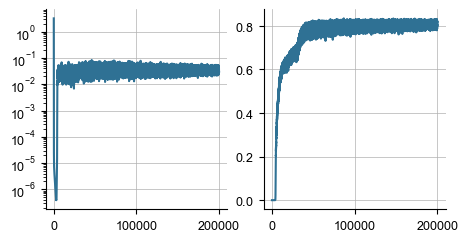

In [14]:
sphere_training(sphere_ensemble_2D[0], n_epochs=200000, eta=1)
fig, axs = plt.subplots(ncols=2, figsize=(4, 2))
axs[0].plot(sphere_ensemble_2D[0]['pred_loss'])
axs[0].set(yscale='log')
axs[1].plot(sphere_ensemble_2D[0]['div_loss'])

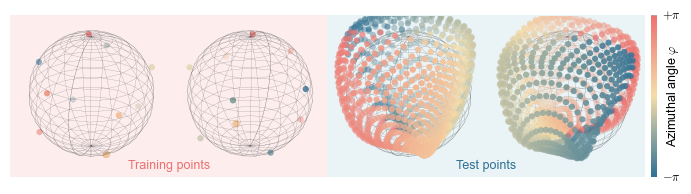

In [15]:
fig, axs = setup_2D_sphere_plot()

# Training points
for i, dsets in enumerate([sphere_ensemble_2D[0]['training_data'], test_dsets_2D]):
    points = sphere_ensemble_2D[0]['NN'](dsets).detach()
    azim_angles = torch.stack([torch.arctan2(*p) for p in points[:, :-1]])
    for j in range(2):
       axs[2*i+j].scatter(*points.transpose(0, 1), c=azim_angles, lw=0, cmap=cm.cmap, vmin=-torch.pi, vmax=torch.pi)

Let's train the larger system.

100%|██████████| 200000/200000 [02:31<00:00, 1316.59it/s]


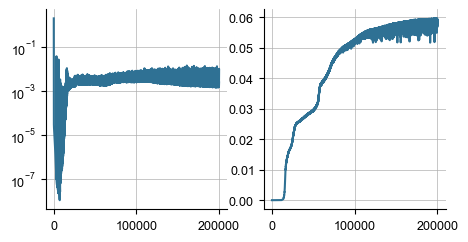

In [16]:
sphere_training(sphere_ensemble_2D[-1], n_epochs=200000, eta=1)
fig, axs = plt.subplots(ncols=2, figsize=(4, 2))
axs[0].plot(sphere_ensemble_2D[-1]['pred_loss'])
axs[0].set(yscale='log')
axs[1].plot(sphere_ensemble_2D[-1]['div_loss'])

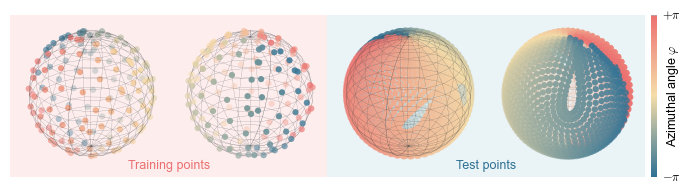

In [17]:
fig, axs = setup_2D_sphere_plot()

# Plot the results on the training and test set
for i, dsets in enumerate([sphere_ensemble_2D[-1]['training_data'], test_dsets_2D]):
    points = sphere_ensemble_2D[-1]['NN'](dsets).detach()
    azim_angles = torch.stack([torch.arctan2(*p) for p in points[:, :-1]])
    for j in range(2):
       axs[2*i+j].scatter(*points.transpose(0, 1), c=azim_angles, lw=0, cmap=cm.cmap, vmin=-torch.pi, vmax=torch.pi)